In [101]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================
!pip install evaluate
import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from datasets import Dataset

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
import evaluate

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shuyangli94/food-com-recipes-and-user-interactions/RAW_interactions.csv
/kaggle/input/datasets/shuyangli94/food-com-recipes-and-user-interactions/ingr_map.pkl
/kaggle/input/datasets/shuyangli94/food-com-recipes-and-user-interactions/PP_recipes.csv
/kaggle/input/datasets/shuyangli94/food-com-recipes-and-user-interactions/RAW_recipes.csv
/kaggle/input/datasets/shuyangli94/food-com-recipes-and-user-interactions/interactions_train.csv
/kaggle/input/datasets/shuyangli94/food-com-recipes-and-user-interactions/interactions_test.csv
/kaggle/input/datasets/shuyangli94/food-com-recipes-and-user-interactions/PP_users.csv
/kaggle/input/datasets/shuyangli94/food-com-recipes-and-user-interactions/interactions_validation.csv


In [3]:
# =====================================================
# 2. LOAD DATASET
# =====================================================
df = pd.read_csv("/kaggle/input/datasets/shuyangli94/food-com-recipes-and-user-interactions/RAW_recipes.csv")

print(df.shape)
df.head()

(231637, 12)


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [4]:
# =====================================================
# 3. KEEP RELEVANT COLUMNS
# =====================================================
df = df[['name', 'minutes', 'nutrition', 'n_steps', 'steps', 'ingredients', 'n_ingredients']]
print(df.shape)

(231637, 7)


In [5]:
# =====================================================
# 4. REMOVE NULL VALUES
# =====================================================
df.dropna(inplace=True)
print(df.shape)

(231636, 7)


In [6]:
# =====================================================
# 5. REMOVE DUPLICATES
# =====================================================
df.drop_duplicates(subset=['name', 'ingredients'], inplace=True)
print(df.shape)

(231624, 7)


In [7]:
# =====================================================
# 6. CONVERT STRING LISTS TO PYTHON LISTS
# =====================================================
def safe_eval(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

df["ingredients"] = df["ingredients"].apply(safe_eval)
df["steps"] = df["steps"].apply(safe_eval)
df["nutrition"] = df["nutrition"].apply(safe_eval)

In [8]:
# =====================================================
# 7. FILTER BAD ROWS
# =====================================================
df = df[df["ingredients"].apply(len) > 1]
df = df[df["steps"].apply(len) > 1]
df = df[df["nutrition"].apply(len) == 7]

# remove unrealistic cooking times
df = df[(df["minutes"] > 0) & (df["minutes"] < 500)]

# ingredient count filter
df = df[(df["n_ingredients"] >= 2) & (df["n_ingredients"] <= 20)]

print(df.shape)

(221835, 7)


In [9]:
# =====================================================
# 8. TEXT CLEANING
# =====================================================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["name"] = df["name"].apply(clean_text)

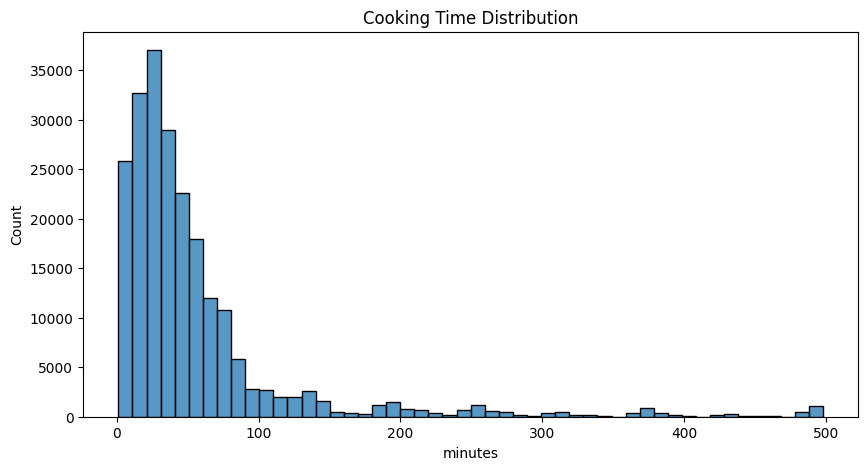

In [10]:
# =====================================================
# 9. VISUALIZATION
# =====================================================

plt.figure(figsize=(10,5))
sns.histplot(df["minutes"], bins=50)
plt.title("Cooking Time Distribution")
plt.show()

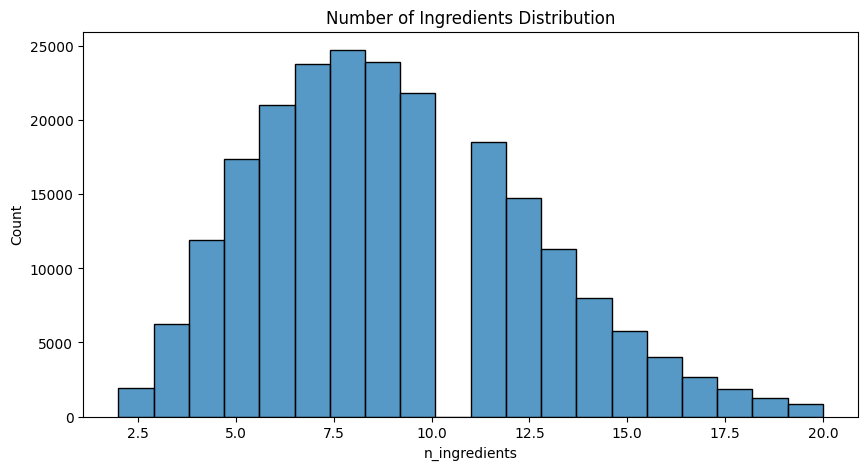

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(df["n_ingredients"], bins=20)
plt.title("Number of Ingredients Distribution")
plt.show()

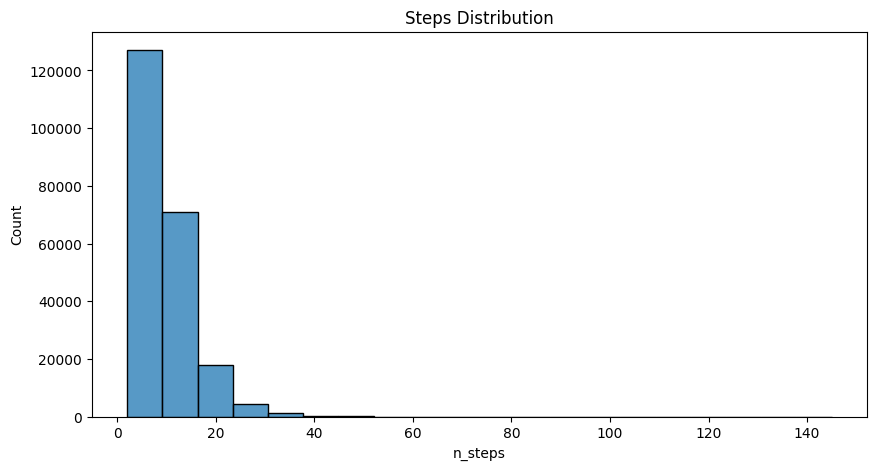

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df["n_steps"], bins=20)
plt.title("Steps Distribution")
plt.show()

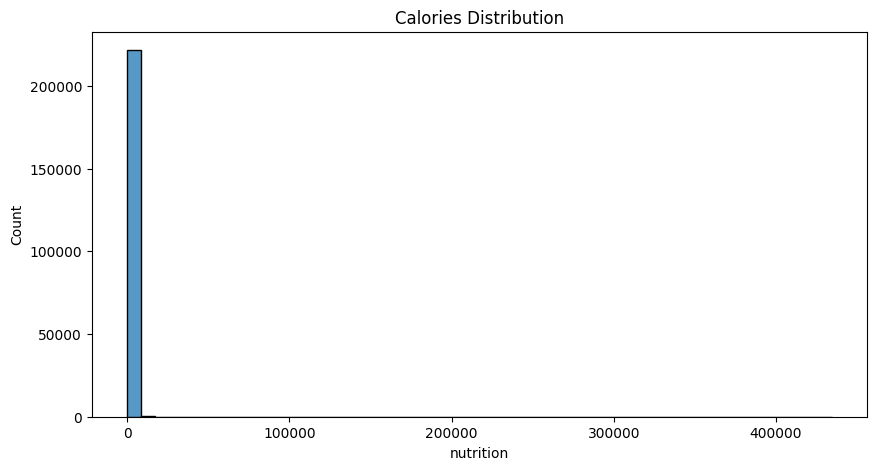

In [13]:
# calories distribution
calories = df["nutrition"].apply(lambda x: x[0])

plt.figure(figsize=(10,5))
sns.histplot(calories, bins=50)
plt.title("Calories Distribution")
plt.show()

In [14]:
# =====================================================
# 10. RANDOM SAMPLE FOR TRAINING
# =====================================================
df = df.sample(n=20000, random_state=42).reset_index(drop=True)

In [15]:
# =====================================================
# 11. FORMAT INPUT / OUTPUT
# =====================================================
def format_row(row):
    
    ingredients = ", ".join(row["ingredients"])
    steps = " ".join(row["steps"])
    n = row["nutrition"]
    
    nutrition_text = f"""
        Calories: {n[0]}
        Fat: {n[1]}%
        Sugar: {n[2]}%
        Sodium: {n[3]}%
        Protein: {n[4]}%
        SatFat: {n[5]}%
        Carbs: {n[6]}%
        """
    
    input_text = f"Generate recipe using only these ingredients: {ingredients}"
    
    target_text = f"""
Recipe Name: {row['name']}
Steps: {steps}
Nutrition:
{nutrition_text}
"""
    
    return pd.Series([input_text, target_text])

df[["input_text","target_text"]] = df.apply(format_row, axis=1)

In [16]:
dataset = Dataset.from_pandas(df[["input_text","target_text"]])
dataset = dataset.train_test_split(test_size=0.1)

In [17]:
model_id = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_id)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [18]:
def tokenize(batch):
    model_inputs = tokenizer(batch["input_text"], max_length=256, truncation=True)

    labels = tokenizer(batch["target_text"], max_length=512, truncation=True)

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

tokenized = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [19]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_id)

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [20]:
!pip install -q -U transformers datasets accelerate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 88.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 95.7 MB/s eta 0:00:00:00:01


In [21]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./recipe_model",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-4,
    num_train_epochs=8,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    gradient_accumulation_steps=4,

    fp16=True,

    predict_with_generate=True,
    logging_steps=500,

    save_total_limit=2,
    load_best_model_at_end=True,

    report_to="none"
)

In [22]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

In [23]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    processing_class=tokenizer,
    data_collator=data_collator
)

In [24]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,23.659820,4.796792
2,18.458568,4.073483
3,16.575143,3.790943
4,15.352326,3.632922
5,14.721110,3.533174
6,14.314514,3.474835
7,14.079798,3.444100
8,13.860890,3.434997


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


TrainOutput(global_step=9000, training_loss=17.296062608506944, metrics={'train_runtime': 16154.4131, 'train_samples_per_second': 8.914, 'train_steps_per_second': 0.557, 'total_flos': 1.0777074990170112e+16, 'train_loss': 17.296062608506944, 'epoch': 8.0})

In [25]:
trainer.save_model("/kaggle/working/recipe_model")
tokenizer.save_pretrained("/kaggle/working/recipe_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/recipe_model/tokenizer_config.json',
 '/kaggle/working/recipe_model/tokenizer.json')

In [96]:
def generate_recipe(ingredients):
    
    prompt = f"Generate recipe using only these ingredients: {ingredients}"
    
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    output = model.generate(
        **inputs,
        max_length=512,
        num_beams=4,
        early_stopping=True
    )
    
    return tokenizer.decode(output[0], skip_special_tokens=True)

generate_recipe("banana, chocolate, flour")

'Recipe Name: banana chocolate fudge Steps: preheat oven to 350 degrees f place bananas in a greased 9x13 inch baking pan sprinkle with chocolate and flour bake at 350 degrees f for 20-25 minutes or until a toothpick inserted in the center comes out clean Nutrition: Calories: 59.8 Fat: 0.0% Sugar: 16.0% Sodium: 0.0% Protein: 1.0% SatFat: 0.0% Carbs: 1.0%'

In [97]:
def generate_recipe(ingredients):

    prompt = f"""
Generate a recipe using only these ingredients:
{ingredients}

Return a simple recipe with:
- Recipe name
- cooking steps
- nutrition information
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to("cuda")

    output = model.generate(
        **inputs,
        max_new_tokens=350,
        num_beams=4,
        length_penalty=1.2,
        repetition_penalty=1.2,
        no_repeat_ngram_size=3,
        early_stopping=False
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)
    

In [94]:
def enforce_steps(text):

    if "Steps:" in text:
        parts = text.split("Steps:")
        before = parts[0]
        after = parts[1]

        steps = after.split("Nutrition:")[0].strip()

        # force splitting into steps
        sentences = steps.replace(",", ".").split(".")

        clean_steps = ""
        count = 1

        for s in sentences:
            s = s.strip()
            if len(s) > 3:
                clean_steps += f"{count}. {s}\n"
                count += 1

        return before + "Steps:\n" + clean_steps + "\nNutrition:" + after.split("Nutrition:")[-1]

    return text

In [95]:
raw = generate_recipe("banana, chocolate, flour")
print(enforce_steps(raw))

Recipe Name: banana chocolate fudge Steps:
1. place bananas and chocolate in a large bowl add flour and mix well pour into a greased 9x13 pan and bake at 350 degrees for 30 minutes

Nutrition: Calories: 69.8 Fat: 0.0% Sugar: 58.0% Sodium: 1.0% Protein: 2.0% SatFat: 0.5% Carbs: 4.0%


In [98]:
def beautify_recipe(text):

    text = text.replace("Recipe Name:", "\nRecipe Name:\n")
    text = text.replace("Steps:", "\nSteps:\n")
    text = text.replace("Nutrition:", "\nNutritional Analysis:\n")

    if "Steps:" in text:
        parts = text.split("Steps:", 1)  # ONLY first split
        before = parts[0]
        after = parts[1]

        if "Nutritional Analysis:" in after:
            step_part, nutri = after.split("Nutritional Analysis:", 1)  # ONLY first split
        else:
            step_part = after
            nutri = ""

        sentences = step_part.strip().split(".")
        formatted_steps = ""

        step_num = 1
        for s in sentences:
            s = s.strip()
            if s:
                formatted_steps += f"{step_num}. {s}\n"
                step_num += 1

        text = before + "Steps:\n" + formatted_steps + "\nNutritional Analysis:\n" + nutri

    return text

In [99]:
raw = generate_recipe("banana, chocolate, flour")
print(beautify_recipe(raw))


Recipe Name:
 banana chocolate fudge 
Steps:
1. place bananas and chocolate in a large bowl add flour and mix well pour into a greased 9x13 pan and bake at 350 degrees for 30 minutes

Nutritional Analysis:

 Calories: 69.8 Fat: 0.0% Sugar: 58.0% Sodium: 1.0% Protein: 2.0% SatFat: 0.5% Carbs: 4.0%


In [28]:
import shutil

# Zip the entire folder
shutil.make_archive(
    "/kaggle/working/recipe_model",   # output zip path (without .zip)
    "zip",                           # format
    "/kaggle/working/recipe_model"   # folder to compress
)

print("Zipped successfully: /kaggle/working/recipe_model.zip")

Zipped successfully: /kaggle/working/recipe_model.zip


In [102]:
rouge = evaluate.load("rouge")

predictions = ["generated recipe text"]
references = ["actual recipe text"]

results = rouge.compute(
    predictions=predictions,
    references=references
)

print(results)

{'rouge1': np.float64(0.6666666666666666), 'rouge2': np.float64(0.5), 'rougeL': np.float64(0.6666666666666666), 'rougeLsum': np.float64(0.6666666666666666)}


In [103]:
bleu = evaluate.load("bleu")

results = bleu.compute(
    predictions=["generated text"],
    references=[["true text"]]
)

print(results)

{'bleu': 0.0, 'precisions': [0.5, 0.0, 0.0, 0.0], 'brevity_penalty': 1.0, 'length_ratio': 1.0, 'translation_length': 2, 'reference_length': 2}


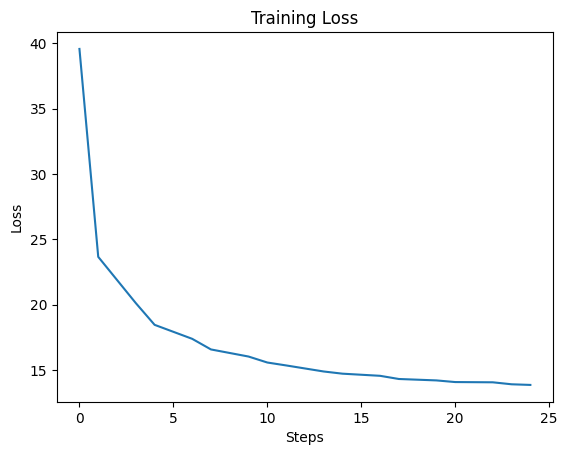

In [105]:
logs = trainer.state.log_history
df = pd.DataFrame(logs)

plt.plot(df["loss"].dropna())
plt.title("Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()